# Section 1

Question: After HDB Resale Portal launched (Jan 2018), did it reduce business for property agents?

Quantification of "business impact on agents" through:
1. Transaction volume with agents
- How many resale deals involved agents over time?
2. Market share of afents
- Of all HDB resale transactions, what % went through agents vs DIY?

The idea is compare 2017 (pre-portal) to 2018 onward (post-portal)

## CEA Salespersons' Property Transaction Records

In [17]:
import pandas as pd

cea_df = pd.read_csv("./CEASalespersonsPropertyTransactionRecordsresidential.csv")
cea_df['transaction_date_parsed'] = pd.to_datetime(cea_df['transaction_date'], format='%b-%Y')
cea_df = cea_df[cea_df['transaction_date_parsed'] >= '2017-01-01']
cea_df = cea_df[(cea_df['property_type'] == 'HDB') & (cea_df['transaction_type'] == 'RESALE')]
cea_df['year'] = cea_df['transaction_date_parsed'].dt.year
cea_df['year_month'] = cea_df['transaction_date_parsed'].dt.to_period('M').astype(str)

display(cea_df.head())
print(cea_df.shape)

print("Number of resale transactions involving agents per month...")
cea_df_monthly = (
    cea_df.groupby('year_month')
       .agg(agent_txn_count=('salesperson_reg_num', 'count'))
       .reset_index()
)

display(cea_df_monthly.head())
print(cea_df_monthly.shape)

,salesperson_name,transaction_date,salesperson_reg_num,property_type,transaction_type,represented,town,district,general_location,transaction_date_parsed,year,year_month
0,SOH HUI HUA,OCT-2017,P000003I,HDB,RESALE,SELLER,YISHUN,-,-,2017-10-01,2017,2017-10
1,SOH HUI HUA,MAR-2018,P000003I,HDB,RESALE,BUYER,KALLANG/WHAMPOA,-,-,2018-03-01,2018,2018-03
2,SOH HUI HUA,JAN-2017,P000003I,HDB,RESALE,BUYER,YISHUN,-,-,2017-01-01,2017,2017-01
3,SOH HUI HUA,MAY-2018,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,-,-,2018-05-01,2018,2018-05
4,SOH HUI HUA,NOV-2017,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,-,-,2017-11-01,2017,2017-11


(345472, 12)
Number of resale transactions involving agents per month...


,year_month,agent_txn_count
0,2017-01,2453
1,2017-02,2596
2,2017-03,2310
3,2017-04,2468
4,2017-05,2713


(107, 2)


## HDB Resale Flat Prices

In [18]:
hdb_df = pd.read_csv("Resale flat prices based on registration date from Jan-2017 onwards.csv")
hdb_df["month_parsed"] = pd.to_datetime(hdb_df["month"])
hdb_df = hdb_df[hdb_df["month_parsed"] >= "2017-01-01"]
hdb_df["year"] = hdb_df["month_parsed"].dt.year
hdb_df["year_month"] = hdb_df["month_parsed"].dt.to_period("M").astype(str)

display(hdb_df.head())
print(hdb_df.shape)

print("Monthly totals across Singapore...")
hdb_monthly = hdb_df.groupby("year_month").agg(total_txn_count=("month", "count"), total_resale_value=("resale_price", "sum"), avg_resale_price=("resale_price", "mean")).reset_index()
display(hdb_monthly.head())
print(hdb_monthly.shape)

print("Town-level breakdowns...")
hdb_town_month = hdb_df.groupby(["year_month", "town"]).agg(total_txn_count=("month", "count"), avg_resale_price=("resale_price", "mean")).reset_index()
display(hdb_town_month.head())
print(hdb_town_month.shape)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,month_parsed,year,year_month
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-01-01,2017,2017-01
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-01-01,2017,2017-01
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-01-01,2017,2017-01
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-01-01,2017,2017-01
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-01-01,2017,2017-01


(219632, 14)
Monthly totals across Singapore...


,year_month,total_txn_count,total_resale_value,avg_resale_price
0,2017-01,1185,5.065958e+08,427506.984810
1,2017-02,1085,4.854276e+08,447398.734562
2,2017-03,1903,8.468919e+08,445029.896942
3,2017-04,1839,8.066392e+08,438629.272235
4,2017-05,1980,8.787029e+08,443789.321212


(107, 4)
Town-level breakdowns...


,year_month,town,total_txn_count,avg_resale_price
0,2017-01,ANG MO KIO,56,413971.214286
1,2017-01,BEDOK,70,408598.400000
2,2017-01,BISHAN,22,604892.181818
3,2017-01,BUKIT BATOK,47,373450.808511
4,2017-01,BUKIT MERAH,56,512267.857143


(2779, 4)


## Compute Agent Market Share

In [26]:
print("Compute total resale volume per month with agent-handled volume per month...")
merged = pd.merge(hdb_monthly, cea_df_monthly, on="year_month",how="left")
merged["agent_txn_count"] = merged["agent_txn_count"].fillna(0)
merged["agent_share"] = merged["agent_txn_count"] / merged["total_txn_count"]
merged["period"] = merged["year_month"].apply(lambda x: "Pre-Portal (2017)" if x < "2018-01" else "Post-Portal (2018+)")
merged.groupby("period").agg(avg_agent_txn=("agent_txn_count", "mean"), avg_total_txn=("total_txn_count", "mean"), avg_agent_share=("agent_share", "mean"))

display(merged.head())
print(merged.shape)

Compute total resale volume per month with agent-handled volume per month...


,year_month,total_txn_count,total_resale_value,avg_resale_price,agent_txn_count,agent_share,period
0,2017-01,1185,5.065958e+08,427506.984810,2453,2.070042,Pre-Portal (2017)
1,2017-02,1085,4.854276e+08,447398.734562,2596,2.392627,Pre-Portal (2017)
2,2017-03,1903,8.468919e+08,445029.896942,2310,1.213873,Pre-Portal (2017)
3,2017-04,1839,8.066392e+08,438629.272235,2468,1.342034,Pre-Portal (2017)
4,2017-05,1980,8.787029e+08,443789.321212,2713,1.370202,Pre-Portal (2017)


(107, 7)


## Plots

Agent Vs Total Monthly Transactions


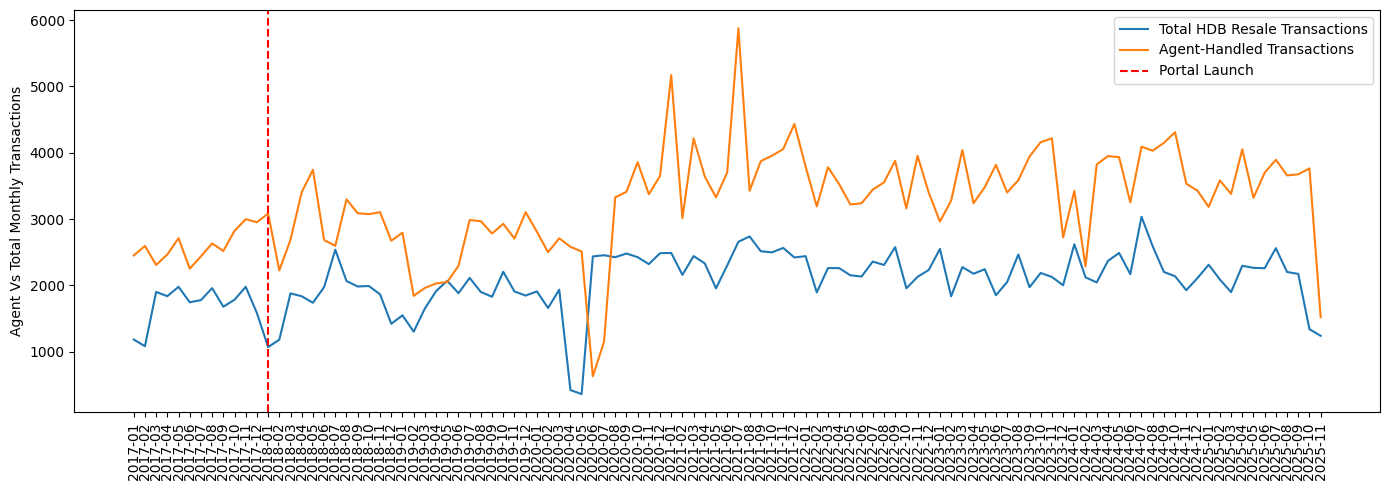

Agent share over time


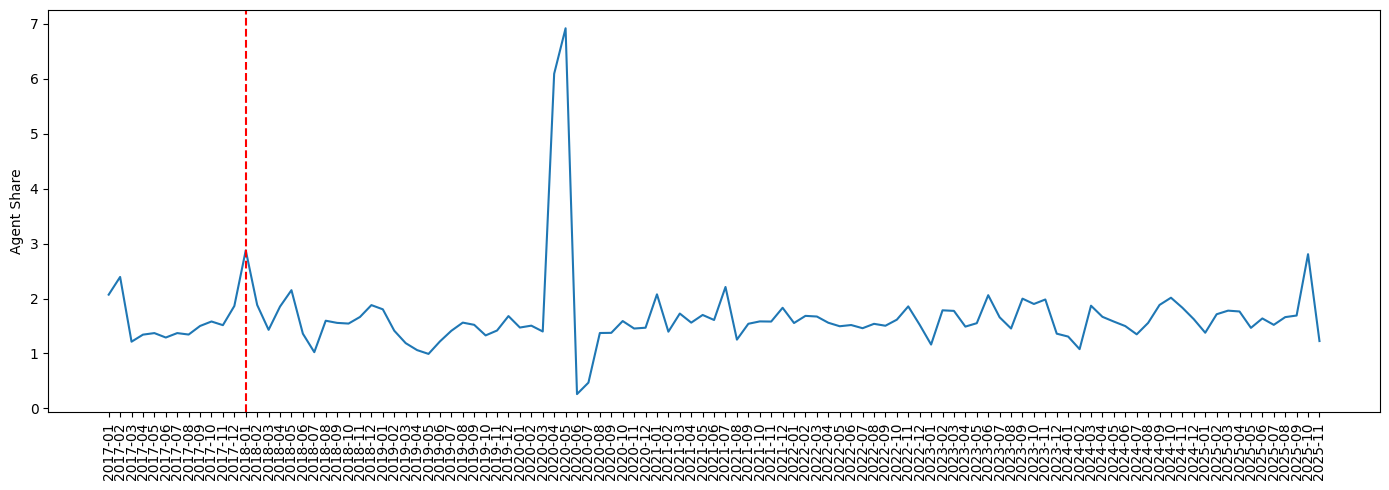

In [30]:
import matplotlib.pyplot as plt

print("Agent Vs Total Monthly Transactions")
plt.figure(figsize=(14,5))
plt.plot(merged["year_month"], merged["total_txn_count"], label="Total HDB Resale Transactions")
plt.plot(merged["year_month"], merged["agent_txn_count"], label="Agent-Handled Transactions")
plt.axvline(x="2018-01", color="red", linestyle="--", label="Portal Launch")
plt.xticks(rotation=90)
plt.ylabel("Agent Vs Total Monthly Transactions")
plt.legend()
plt.tight_layout()
plt.show()

print("Agent share over time")
plt.figure(figsize=(14,5))
plt.plot(merged["year_month"], merged["agent_share"], label="Agent Market Share (%)")
plt.axvline(x="2018-01", color="red", linestyle="--")
plt.xticks(rotation=90)
plt.ylabel("Agent Share")
plt.tight_layout()
plt.show()